In [1]:
import numpy as np
import pandas as pd
import category_encoders as ce
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [8]:
!pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)


In [2]:
# ==============================================================================-
# 1. CONFIGURAÇÕES
# ==============================================================================
TARGET = 'temperaturasaidafp'
WOE_COL = ['qualidade']
OHE_COL = ['panela']
# Sugestão do legado não entra como feature para evitar dependência direta,
# mas o modelo aprende a dinâmica pelos outros dados.
COLS_TO_EXCLUDE_FROM_X = ['sugestaomodelolegado', 'temperaturamediareal', 'temperaturaobjetivada']

VAL_INICIO = 7000
DELTA_NEG = 5
DELTA_POS = 10

In [3]:
# ==============================================================================
# 2. FUNÇÃO DE PERDA ASSIMÉTRICA
# ==============================================================================
def custom_asymmetric_loss(y_true, y_pred):
    resid = y_pred - y_true
    alpha = 1.3
    factor = np.where(resid < 0, alpha, 1.0)
    grad = 2.0 * resid * factor
    hess = 2.0 * factor
    return grad, hess


In [4]:
# ==============================================================================
# 3. CARREGAMENTO E PREPARAÇÃO
# ==============================================================================
print("--- 1. Carregando Dados ---")
df = pd.read_csv('dados_fundo_do_amanha_evcomx.csv', delimiter=';')

#df = df[df[TARGET].between(df[TARGET].quantile(0.001),df[TARGET].quantile(0.999))]

# REMOÇÃO DE DUPLICATAS
df = df.drop_duplicates(subset=['corrida'], keep='first')

num_cols = ['al_min','c_min','c_max','n_min','s_min','sequencia','sequenciatotal',
            'vidapanela','tempociclo','tempovacuototal','temperaturaliquidus',
            'velocidadeobjetivada','velocidadereal','sugestaomodelolegado',
            'temperaturasaidafp','temperaturaobjetivada','temperaturamediareal']
for c in num_cols:
    if c in df.columns: df[c] = pd.to_numeric(df[c], errors='coerce')

id_cols = ['corrida','secao','acoatual','qualidade','panela']
for c in id_cols:
    if c in df.columns: df[c] = df[c].fillna('MISSING').astype(str)

df['C_Medio'] = (df['c_max'] + df['c_min']) / 2
df['T_Liquid_Desvio'] = df['temperaturaobjetivada'] - df['temperaturaliquidus']
df['Desvio_Legado_Target'] = df['sugestaomodelolegado'] - df['temperaturaobjetivada']
df['Tempo_Sequencia'] = df['tempociclo'] * df['sequencia']

cols_to_drop_early = ['acoatual','corrida','secao','c_min','c_max',
                      'temperaturaliquidus','velocidadeobjetivada','velocidadereal','s_min']
df_clean = df.drop(columns=[c for c in cols_to_drop_early if c in df.columns], errors='ignore')

--- 1. Carregando Dados ---


In [5]:
# ==============================================================================
# 4. SPLIT GOLDEN BATCH (MODELO ÚNICO)
# ==============================================================================
print(f"\n--- 2. Separando Conjuntos (Estratégia Elite) ---")

# 1. Validação (Futuro)
df_valid = df_clean.iloc[VAL_INICIO:].copy()

# 2. Treino Total (Passado)
df_treino_total = df_clean.iloc[:VAL_INICIO].copy()

# 3. Filtro Elite (Golden Batch)
# Critério: Resultado Real ficou entre -5 e +10 do Objetivo?
erro_real_treino = (df_treino_total['temperaturamediareal']) - df_treino_total['temperaturaobjetivada']
mask_gold = (erro_real_treino >= -DELTA_NEG) & (erro_real_treino <= DELTA_POS)

df_treino_gold = df_treino_total[mask_gold].copy()    # ELITE (Treino)
df_treino_dirty = df_treino_total[~mask_gold].copy()  # SUJOS (Teste)

print(f"Treino ELITE (Apenas Acertos): {len(df_treino_gold)}")
print(f"Dados SUJOS (Recuperação): {len(df_treino_dirty)}")
print(f"Validação (Futuro): {len(df_valid)}")

# Função auxiliar para separar X e Y
def split_XY(df_part):
    Y = df_part[TARGET].copy()
    X = df_part.drop(columns=[TARGET] + COLS_TO_EXCLUDE_FROM_X, errors='ignore')
    return X, Y

# Criação dos Datasets (Sem separar Usou/Op)
X_elite, Y_elite = split_XY(df_treino_gold)
X_valid, Y_valid = split_XY(df_valid)
X_dirty, Y_dirty = split_XY(df_treino_dirty)


--- 2. Separando Conjuntos (Estratégia Elite) ---
Treino ELITE (Apenas Acertos): 4383
Dados SUJOS (Recuperação): 2617
Validação (Futuro): 485


In [6]:
# ==============================================================================
# 5. ENCODING (ÚNICO)
# ==============================================================================
print("\n--- 3. Aplicando Encoders ---")

# Treina o encoder APENAS na Elite
te = ce.TargetEncoder(cols=WOE_COL)
X_elite_te = te.fit_transform(X_elite, Y_elite)
X_elite_final = pd.get_dummies(X_elite_te, columns=OHE_COL, drop_first=True)

# Aplica nos outros conjuntos
def aplicar_encoder(X_raw, encoder_treinado, colunas_modelo):
    X_te = encoder_treinado.transform(X_raw.copy())
    X_final = pd.get_dummies(X_te, columns=OHE_COL, drop_first=True)
    # Garante as mesmas colunas do treino
    X_final = X_final.reindex(columns=colunas_modelo, fill_value=0)
    return X_final

colunas_mestras = X_elite_final.columns
X_valid_final = aplicar_encoder(X_valid, te, colunas_mestras)
X_dirty_final = aplicar_encoder(X_dirty, te, colunas_mestras)


--- 3. Aplicando Encoders ---


In [14]:
from sklearn.linear_model import ElasticNetCV
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from copy import deepcopy
from sklearn.base import clone
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF




best_params = {
    'n_estimators': 1500, # Um pouco mais de árvores para compensar a unificação
    'learning_rate': 0.10,
    'max_depth': 8,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'min_child_weight': 15,
    'reg_lambda': 0.01,
    'alpha': 0.01,
    "objective": custom_asymmetric_loss,
    "booster": "gbtree",
    "tree_method": "hist", "device": "cuda", "random_state": 42,
    "verbosity": 0, "n_jobs": -1
}

base_models = [

    # 2. LightGBM
    ("lgbm", LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        num_leaves=31,
        random_state=42
    )),

    # 3. CatBoost
    ("cat", CatBoostRegressor(
        depth=8,
        iterations=600,
        learning_rate=0.05,
        loss_function="RMSE",
        verbose=False,
        random_seed=42
    )),

    # 4. XGBoost
    ("xgb", XGBRegressor(**best_params)),

    # 5. KNN (normalizado)
    ("knn", Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(
            n_neighbors=15,
            weights="distance",
            metric="manhattan"
        ))
    ])),

    # 6. Gaussian Process Regressor (suaviza previsões)
    ("gpr", GaussianProcessRegressor(
        kernel=RBF(length_scale=1.0),
        alpha=1.0,
        normalize_y=True
    ))
]

# ============================================================
# 2. META-MODELO (FINAL ESTIMATOR)
# ============================================================

# META-MODELO — LightGBM funciona melhor com previsões baseadas em sensores
final_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)

# ============================================================
# 3. STACKING REGRESSOR
# ============================================================

model_unique = StackingRegressor(
    estimators=base_models,
    final_estimator=final_model,
    passthrough=False,
)

model_unique.fit(X_elite_final, Y_elite)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000180 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1129
[LightGBM] [Info] Number of data points in the train set: 4383, number of used features: 23
[LightGBM] [Info] Start training from score 1653.179101
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002959 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1097
[LightGBM] [Info] Number of data points in the train set: 3506, number of used features: 21
[LightGBM] [Info] Start training from score 1653.279806
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000178 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1105
[LightGBM] [Info] Number of data points in the train set: 3506, number of used features: 23
[LightGBM] [Info] Start 

,estimators,"[('lgbm', ...), ('cat', ...), ...]"
,final_estimator,LGBMRegressor...subsample=0.7)
,cv,None
,n_jobs,None
,passthrough,False
,verbose,0
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500


In [10]:
# ==============================================================================
# 6. TREINO (MODELO ÚNICO)
# ==============================================================================
best_params = {
    'n_estimators': 1500, # Um pouco mais de árvores para compensar a unificação
    'learning_rate': 0.10,
    'max_depth': 8,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'min_child_weight': 15,
    'reg_lambda': 0.01,
    'alpha': 0.01,
    "objective": custom_asymmetric_loss,
    "booster": "gbtree",
    "tree_method": "hist", "device": "cuda", "random_state": 42,
    "verbosity": 0, "n_jobs": -1
}

print("\n--- 4. Treinando Modelo Único (XGBoost) ---")
model_unique = XGBRegressor(**best_params)
model_unique.fit(X_elite_final, Y_elite)


--- 4. Treinando Modelo Único (XGBoost) ---


,objective,<function cus...00160DD07A660>
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [15]:
# ==============================================================================
# 7. CÁLCULO DO VIÉS
# ==============================================================================
# Predição na Elite para calcular a calibração
p_tr_elite = model_unique.predict(X_elite_final)
vies_calculado = np.mean(p_tr_elite - Y_elite)

print(f"\n>>> VIÉS DETECTADO NA ELITE: {vies_calculado:.2f} °C")


>>> VIÉS DETECTADO NA ELITE: -0.00 °C


In [16]:

# ==============================================================================
# 8. FUNÇÃO DE AVALIAÇÃO SIMPLIFICADA
# ==============================================================================
def avaliar_cenario_unico(X_input, df_orig, Y_orig, nome_dataset, usar_vies=False):
    print(f"\n>>> AVALIANDO: {nome_dataset} (Correção: {usar_vies})")

    # 1. Predição Única
    pred_raw = model_unique.predict(X_input)

    # 2. Aplicação do Viés
    if usar_vies:
        pred_final = pred_raw - 2
    else:
        pred_final = pred_raw

    # 3. Cálculo dos Erros (Fórmula Complexa)
    # Legado
    diff_legado = df_orig['sugestaomodelolegado'] - df_orig[TARGET]
    erro_legado = (df_orig['temperaturamediareal'] + diff_legado) - df_orig['temperaturaobjetivada']

    # Novo Modelo
    diff_novo = pred_final - df_orig[TARGET]
    erro_novo = (df_orig['temperaturamediareal'] + diff_novo) - df_orig['temperaturaobjetivada']

    # 4. Categorização e Stats
    df_plot = pd.DataFrame({'Legado': erro_legado, 'Novo': erro_novo})

    def categorizar(val):
        if val < -DELTA_NEG: return '1. Frio'
        elif val > DELTA_POS: return '3. Quente'
        else: return '2. Acerto'

    df_plot['Cat_Legado'] = df_plot['Legado'].apply(categorizar)
    df_plot['Cat_Novo'] = df_plot['Novo'].apply(categorizar)

    stats_legado = df_plot['Cat_Legado'].value_counts(normalize=True) * 100
    stats_novo = df_plot['Cat_Novo'].value_counts(normalize=True) * 100

    # 5. Plotagem
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Histograma
    sns.histplot(df_plot['Legado'], color='red', label='Legado', kde=True, ax=axes[0], alpha=0.3, element="step")
    sns.histplot(df_plot['Novo'], color='purple', label='Modelo Único', kde=True, ax=axes[0], alpha=0.3, element="step")
    axes[0].axvline(-DELTA_NEG, color='k', linestyle='--')
    axes[0].axvline(DELTA_POS, color='k', linestyle='--')
    axes[0].set_title(f"Distribuição de Erros - {nome_dataset}")
    axes[0].set_xlabel("Desvio do Objetivo (°C)")
    axes[0].legend()

    # Barras
    categorias = ['1. Frio', '2. Acerto', '3. Quente']
    vals_leg = [stats_legado.get(c, 0) for c in categorias]
    vals_nov = [stats_novo.get(c, 0) for c in categorias]
    x = np.arange(len(categorias))

    bars1 = axes[1].bar(x - 0.17, vals_leg, 0.35, label='Legado', color='red', alpha=0.7)
    bars2 = axes[1].bar(x + 0.17, vals_nov, 0.35, label='Modelo Único', color='purple', alpha=0.7)

    axes[1].set_title(f"Comparação de Desempenho - {nome_dataset}")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(['FRIO (< -5)', 'ACERTO', 'QUENTE (> +10)'])
    axes[1].bar_label(bars1, fmt='%.1f%%', padding=3)
    axes[1].bar_label(bars2, fmt='%.1f%%', padding=3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    resumo = pd.DataFrame({'% Legado': vals_leg, '% Novo': vals_nov}, index=['Frio', 'Acerto', 'Quente'])
    print(resumo.round(2))
    print("="*60)



>>> AVALIANDO: 1. TREINO ELITE (Sem Viés) (Correção: False)


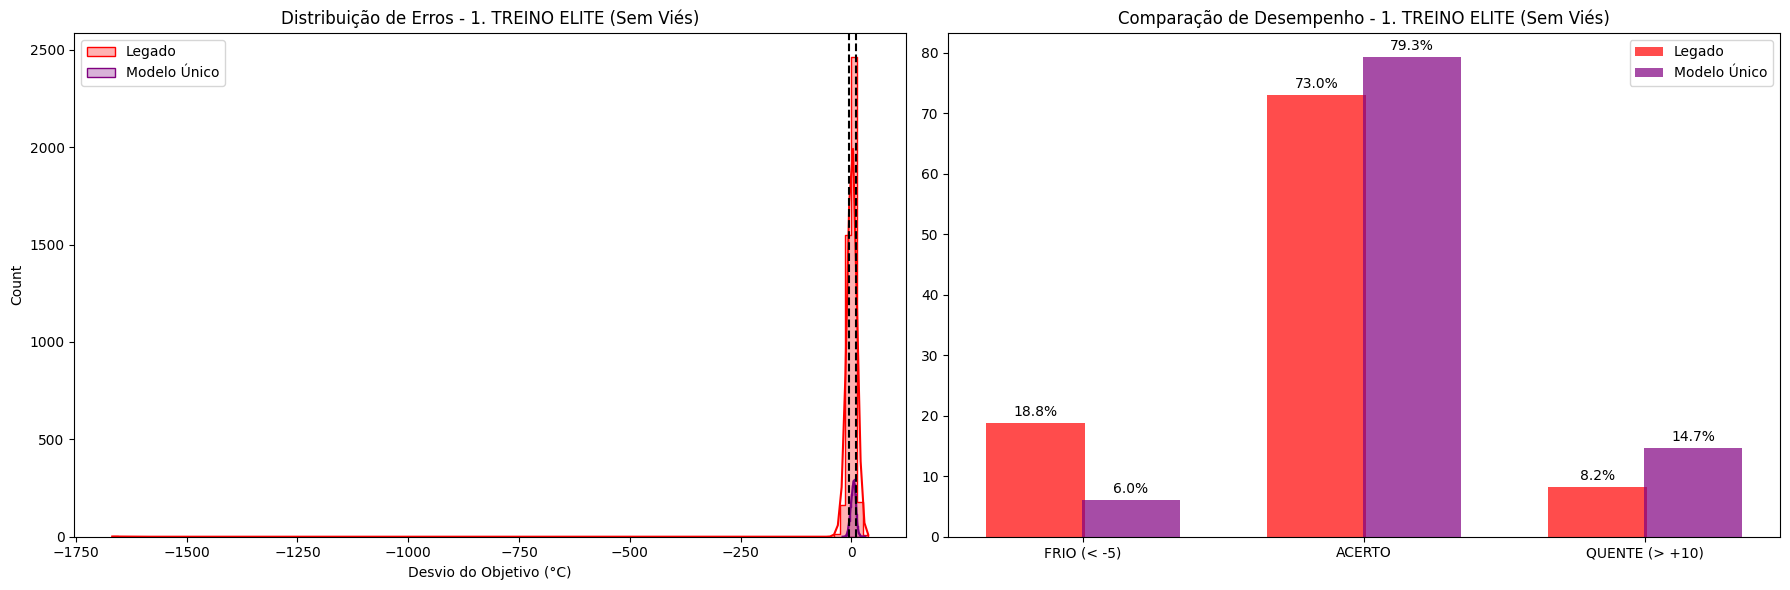

        % Legado  % Novo
Frio       18.75    6.02
Acerto     73.03   79.31
Quente      8.21   14.67

>>> AVALIANDO: 2. DADOS SUJOS (Com Correção) (Correção: True)


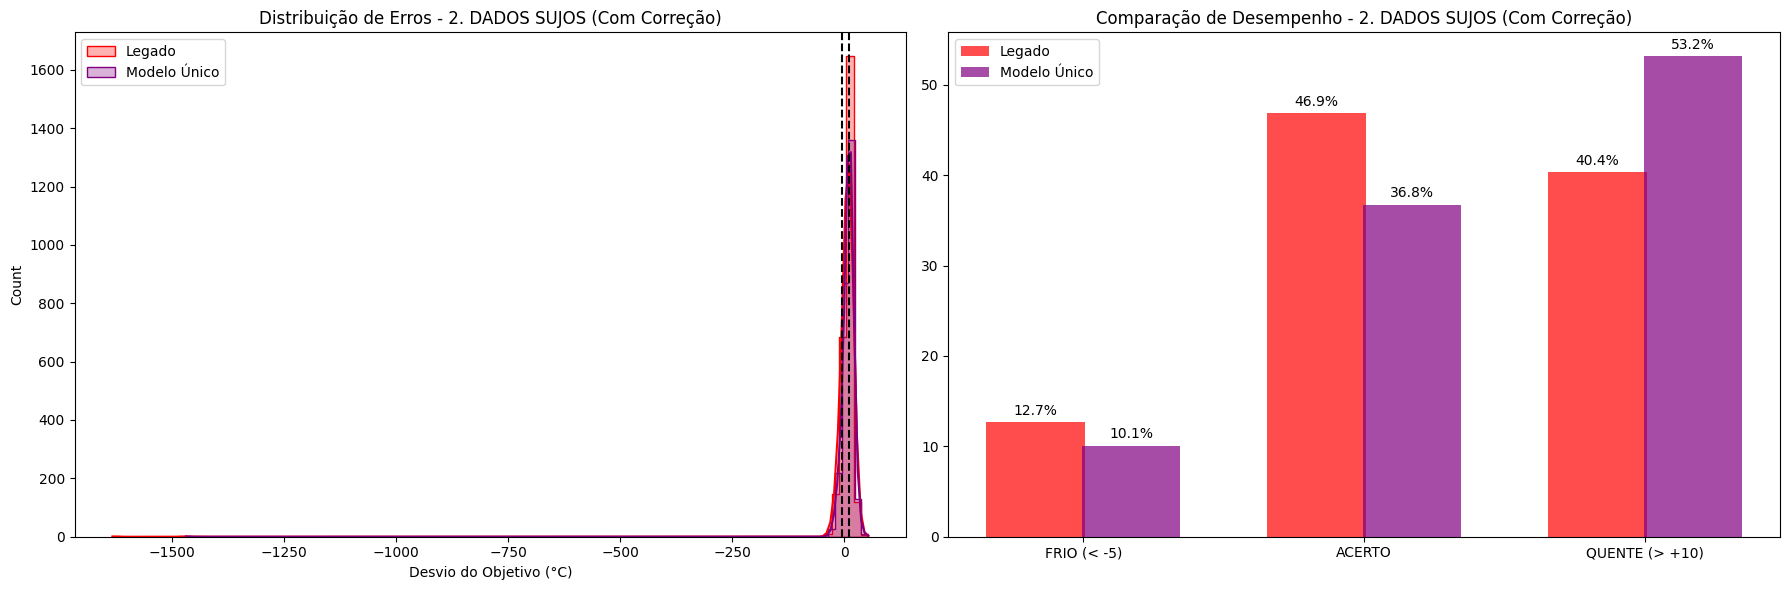

        % Legado  % Novo
Frio       12.72   10.09
Acerto     46.89   36.76
Quente     40.39   53.15

>>> AVALIANDO: 3. VALIDAÇÃO FUTURA (Com Correção) (Correção: True)


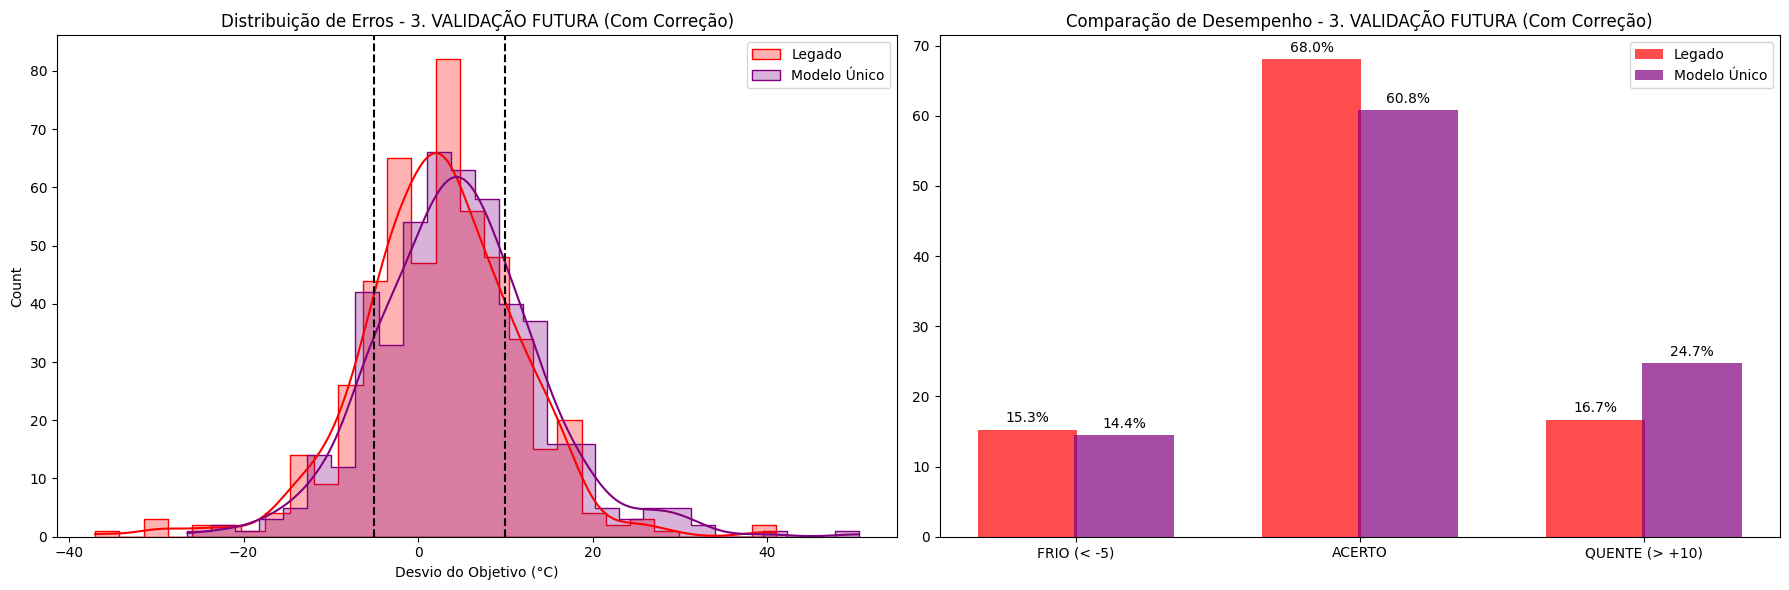

        % Legado  % Novo
Frio       15.26   14.43
Acerto     68.04   60.82
Quente     16.70   24.74


In [17]:
# ==============================================================================
# 9. EXECUÇÃO
# ==============================================================================

# 1. ELITE (Aprendizado Puro)
avaliar_cenario_unico(X_elite_final, df_treino_gold, Y_elite,
                      "1. TREINO ELITE (Sem Viés)", usar_vies=False)

# 2. DADOS SUJOS (Recuperação)
avaliar_cenario_unico(X_dirty_final, df_treino_dirty, Y_dirty,
                      "2. DADOS SUJOS (Com Correção)", usar_vies=True)

# 3. VALIDAÇÃO FUTURA
avaliar_cenario_unico(X_valid_final, df_valid, Y_valid,
                      "3. VALIDAÇÃO FUTURA (Com Correção)", usar_vies=True)